In [10]:
import matplotlib.pyplot as plt 
import numpy as np

# --- 1. Initialisation des constantes ---
nb_agents = 1000
nb_secteurs = 10
n_simulations = 200 # Tu peux remettre 1000, mais 200 ira plus vite pour tester

# Espérances théoriques distinctes pour chaque secteur (l'axe X de notre DL)
esperances_theoriques = np.linspace(0.2, 0.8, nb_secteurs)

# Génération de A et Pi
A_brut = np.random.uniform(0, 1, (nb_agents, nb_secteurs))
A = A_brut / A_brut.sum(axis=1, keepdims=True)
Pi = np.ones(nb_secteurs)

def generer_P(n_agents, n_secteurs, esperances):
    """Génère P avec une loi uniforme [0, 2*E] pour que l'espérance soit E"""
    P = np.zeros((n_agents, n_secteurs))
    for j in range(n_secteurs):
        P[:, j] = np.random.uniform(0, 2 * esperances[j], n_agents)
    return P

In [11]:
def Y(P, Pi):
    return P * Pi 

def J(Y_mat): 
    return np.argmax(Y_mat, axis=1)

def B(P, Pi):
    return np.max(Y(P, Pi), axis=1)

def Offre(P, Pi):
    Omega = np.zeros(nb_secteurs)
    Y_mat = Y(P, Pi)
    choix = J(Y_mat)
    for j in range(nb_secteurs):
        Omega[j] = np.sum(Y_mat[choix == j, j])
    return Omega

def Demande(A, B_vec):
    return B_vec @ A

In [12]:
#calcul des espérances 

#on a bien A et Pi fixés

def esperances(A, Pi, esp_theoriques, n=n_simulations):
    acc_Offre = np.zeros(nb_secteurs)
    acc_Demande = np.zeros(nb_secteurs)
    
    for i in range(n):
        # On utilise bien la nouvelle génération hétérogène à chaque itération !
        P_iter = generer_P(nb_agents, nb_secteurs, esp_theoriques)
        acc_Offre += Offre(P_iter, Pi)
        acc_Demande += Demande(A, B(P_iter, Pi))
        
    return acc_Offre / n, acc_Demande / n

In [13]:
#Résolution pour obtenir Pi solution de l'égalité des espérances

#algo naif
def algo_tatonnement(A, Pi, esp_theoriques, n_iter=200, learning_rate=0.01):
    for i in range(n_iter):
        E_Offre, E_Demande = esperances(A, Pi, esp_theoriques)
        Pi = Pi + learning_rate * (E_Demande - E_Offre)
        
        Pi = np.maximum(Pi, 0.001) 
        Pi = Pi / np.sum(Pi) * nb_secteurs 
        
        erreur = np.max(np.abs(E_Demande - E_Offre))
        if erreur < 1.0: 
            print(f"Équilibre atteint à l'itération {i}")
            break
            
    return Pi



Lancement de la recherche de l'équilibre...

--- Résultats du DL ---
Équation estimée : Pi ≈ (-160.7285)*X^3 + (59.1085)*X^2 + (-5.0575)*X + (0.1695)


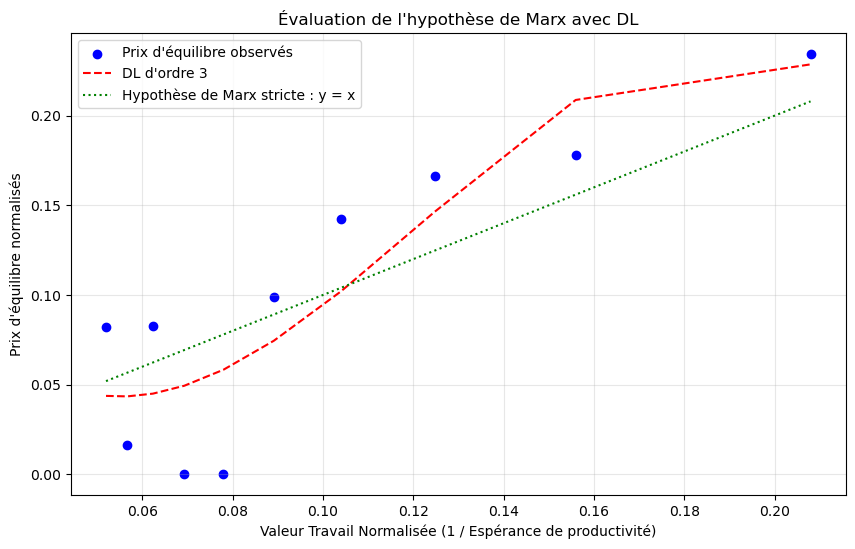

In [14]:
print("Lancement de la recherche de l'équilibre...")
Pi_eq = algo_tatonnement(A, Pi, esperances_theoriques)

# --- 5. Calcul du DL et Tracé ---
# Hypothèse de Marx[cite: 20]: Prix proportionnels à l'inverse de la productivité attendue
X_marx = 1 / esperances_theoriques

# Normalisation 
X_norm = X_marx / np.sum(X_marx)
Pi_eq_norm = Pi_eq / np.sum(Pi_eq)

# Régression polynomiale de degré 3
degre = 3
coefficients = np.polyfit(X_norm, Pi_eq_norm, degre)

print("\n--- Résultats du DL ---")
print(f"Équation estimée : Pi ≈ ({coefficients[0]:.4f})*X^3 + ({coefficients[1]:.4f})*X^2 + ({coefficients[2]:.4f})*X + ({coefficients[3]:.4f})")

# Préparation de la courbe
polynome_dl = np.poly1d(coefficients)
valeurs_ajustees = polynome_dl(X_norm)

# Tri pour le graphique
index_tri = np.argsort(X_norm)
X_tri = X_norm[index_tri]
Pi_tri = Pi_eq_norm[index_tri]
Y_fit_tri = valeurs_ajustees[index_tri]

# Affichage
plt.figure(figsize=(10, 6))
plt.scatter(X_tri, Pi_tri, label="Prix d'équilibre observés", color='blue', marker='o')
plt.plot(X_tri, Y_fit_tri, label=f"DL d'ordre {degre}", color='red', linestyle='--')
plt.plot(X_tri, X_tri, label="Hypothèse de Marx stricte : y = x", color='green', linestyle=':')

plt.title("Évaluation de l'hypothèse de Marx avec DL")
plt.xlabel("Valeur Travail Normalisée (1 / Espérance de productivité)")
plt.ylabel("Prix d'équilibre normalisés")
plt.legend()
plt.grid(alpha=0.3)
plt.show()